
## Case Study 2: Chapter 8 – Security-Constrained Optimal Power Flow (SCOPF)

Authors: Neeraj Dhanraj Bokde (www.neerajbokde.in) and Carlo Fanara

Affiliation: Renewable & Sustainable Energy Research Center, TII, Abu Dhabi

Corresponding author: neeraj.bokde@tii.ae / neerajdhanraj@gmail.com


#### Αυτό το σενάριο (script) υλοποιεί τη μελέτη περίπτωσης SCOPF (Security-Constrained Optimal Power Flow) από το Κεφάλαιο 8 του οδηγού The PyPSA Handbook, χρησιμοποιώντας το δίκτυο των 5 κόμβων που αναλύσαμε προηγουμένως.

Ακολουθεί μια αναλυτική επεξήγηση των βημάτων και της στρατηγικής που ακολουθεί ο κώδικας:

### 1. Τα Στάδια της Προσομοίωσης

Η ροή εργασίας του script χωρίζεται σε τρεις βασικές φάσεις:
- **Βήμα 1**: Βασική Επίλυση (Standard OPF): Το μοντέλο επιλύει πρώτα το δίκτυο υπό κανονικές συνθήκες λειτουργίας (base case), όπου όλα τα στοιχεία είναι πλήρως διαθέσιμα, με μοναδικό στόχο την ελαχιστοποίηση του κόστους.
- **Βήμα 2**: Προσομοίωση Συμβάντων N-1 (Contingency Analysis): Εκτελείται ένας βρόχος (loop) προσομοιώσεων. Σε κάθε επανάληψη, τίθεται εκτός λειτουργίας μία (και μόνο μία) γραμμή μεταφοράς και το δίκτυο επανεπιλύεται (re-optimized) για να δει πώς αντιδρά η ροή ισχύος και αν επαρκούν οι υπόλοιπες γραμμές.
- **Βήμα 3**: Υπολογισμός Συντηρητικής Στρατηγικής (Conservative Dispatch): Συλλέγονται τα δεδομένα παραγωγής από όλες τις παραπάνω επιλύσεις και υπολογίζεται η μέγιστη απαιτούμενη παραγωγή (maximum dispatch) για κάθε γεννήτρια σε όλα τα σενάρια. Αυτό το προφίλ αποτελεί τη βάση για τη «θωράκιση» του συστήματος.

### 2. Τι Αποκαλύπτουν τα Αποτελέσματα

Η σύγκριση των αποτελεσμάτων (μέσω των ραβδογραμμάτων και των πινάκων που παράγει το script) αναδεικνύει τρία κρίσιμα συμπεράσματα:
- **Οικονομικές Υποχωρήσεις (Economic Trade-offs)**: Η εισαγωγή των περιορισμών SCOPF αλλάζει το μείγμα παραγωγής. Το σύστημα αναγκάζεται να μειώσει την παραγωγή από τις πιο φθηνές γεννήτριες (αν η γραμμή εκκένωσής τους κινδυνεύει με υπερφόρτωση) και να ενεργοποιήσει ακριβότερες μονάδες (redispatch). Αυτό αυξάνει το συνολικό λειτουργικό κόστος, το οποίο αποτελεί το «κόστος ασφάλειας» του δικτύου.
- **Εντοπισμός Ευπαθειών (Vulnerability)**: Το script δείχνει ποια σενάρια N-1 προκαλούν Μη Εξυπηρετούμενη Ενέργεια (Unserved Energy). Για παράδειγμα, η απώλεια της ακτινικής γραμμής Line14 θα απομονώσει άμεσα το φορτίο Load 4, αποδεικνύοντας ότι η τοπολογική ευπάθεια δεν μπορεί πάντα να λυθεί μόνο με ανακατανομή της παραγωγής.
- **Ανάγκη για Ευελιξία (Flexibility)**: Φαίνεται στην πράξη ποιες γεννήτριες έχουν τα περιθώρια να αυξήσουν γρήγορα την ισχύ τους για να καλύψουν το κενό των γραμμών που βγαίνουν εκτός λειτουργίας.
Σύνοψη

Το συγκεκριμένο script μετατρέπει τη θεωρία της ανθεκτικότητας σε κώδικα, δείχνοντας πώς το PyPSA μπορεί να χρησιμοποιηθεί όχι απλώς για να σχεδιάσουμε το φθηνότερο δυνατό δίκτυο, αλλά για να προγραμματίσουμε μια ασφαλή και στιβαρή λειτουργία απέναντι στις απρόβλεπτες τεχνικές αστοχίες του πραγματικού κόσμου.


In [5]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Create Base Network

Τα Στάδια της Διαδικασίας Μοντελοποίησης
- Αρχικοποίηση (Initialization): Το δίκτυο ξεκινά ως ένα κενό αντικείμενο pypsa.Network(), το οποίο λειτουργεί ως ο καμβάς πάνω στον οποίο χτίζονται όλα τα στοιχεία.
- Συστηματική Προσθήκη Στοιχείων: * Ορίζονται οι 5 κόμβοι (buses) που θα χρησιμεύσουν ως τα σημεία σύνδεσης.
    - Τοποθετούνται οι 4 γεννήτριες (μία σε κάθε κύριο κόμβο) προσφέροντας ένα διαφοροποιημένο μείγμα τεχνολογιών και κόστους.
    - Εισάγονται τα φορτία (loads), τα οποία τοποθετούνται σκόπιμα για να πιέσουν τόσο την παραγωγή όσο και τις δυνατότητες μεταφοράς του δικτύου.
Κατασκευή Τοπολογίας (Γραμμές Μεταφοράς):
- Οι 4 κύριοι κόμβοι συνδέονται σε κλειστό βρόχο (loop), προσφέροντας εναλλακτικές διαδρομές (πλεονασμό/redundancy).
- Ο 5ος κόμβος συνδέεται ακτινικά (spur connection), δημιουργώντας ένα ευάλωτο σημείο (single-point vulnerability).

Γιατί είναι σημαντική αυτή η συγκεκριμένη δομή;
Αυτή η προσεκτική γεωμετρική και τεχνική διαρρύθμιση αποτελεί το ιδανικό ελεγχόμενο περιβάλλον («εργαστήριο») για:
- Δοκιμή Απώλειας Γραμμών (Line Outages): Επιτρέπει στο PyPSA να δείξει πώς συμπεριφέρεται η ροή ισχύος όταν χάνεται μια γραμμή με εναλλακτική διαδρομή, έναντι μιας γραμμής χωρίς εναλλακτική.
- Μέτρηση Περιθωρίου Ασφαλείας (Security Margin): Ποσοτικοποιεί με διαφανή και επαναλήψιμο τρόπο τα όρια αντοχής του δικτύου πριν αυτό χρειαστεί να καταφύγει σε περικοπές φορτίου.

In [6]:
n = pypsa.Network()
n.set_snapshots(pd.date_range("2025-01-01", periods=1, freq="h"))

# Add 5 buses
for i in range(5):
    n.add("Bus", f"Bus {i}", carrier="AC")

# Add generators (wind, gas, CHP, diesel)
n.add("Generator", "G0", bus="Bus 0", p_nom=100, marginal_cost=0, carrier="wind")
n.add("Generator", "G1", bus="Bus 1", p_nom=80, marginal_cost=50, carrier="gas")
n.add("Generator", "G2", bus="Bus 2", p_nom=40, marginal_cost=40, carrier="chp")
n.add("Generator", "G3", bus="Bus 3", p_nom=100, marginal_cost=200, carrier="diesel")

# Add loads
n.add("Load", "Load1", bus="Bus 1", p_set=50)
n.add("Load", "Load2", bus="Bus 2", p_set=30)
n.add("Load", "Load3", bus="Bus 3", p_set=40)
n.add("Load", "Load4", bus="Bus 4", p_set=80)

# Add transmission lines (loop + radial)
line_params = dict(carrier="AC", x=0.1, r=0.01, s_nom=100)
n.add("Line", "Line_0_1", bus0="Bus 0", bus1="Bus 1", **line_params)
n.add("Line", "Line_1_2", bus0="Bus 1", bus1="Bus 2", **line_params)
n.add("Line", "Line_2_3", bus0="Bus 2", bus1="Bus 3", **line_params)
n.add("Line", "Line_3_0", bus0="Bus 3", bus1="Bus 0", **line_params)
n.add("Line", "Line_1_4", bus0="Bus 1", bus1="Bus 4", **line_params)




### Add high-cost unserved generators at each bus

Ο Ρόλος και η Λειτουργία των Virtual Γεννητριών

Οι εικονικές αυτές μονάδες τοποθετούνται σε κάθε κόμβο (bus) του δικτύου και λειτουργούν ως ο μαθηματικός καθρέφτης της αναγκαστικής περικοπής φορτίου (involuntary load shedding).
- **Η Έσχατη Λύση (Last Resort)**: Αν κατά τη διάρκεια ενός σφάλματος $N-1$ η πραγματική παραγωγή ή το δίκτυο μεταφοράς δεν επαρκούν για να καλύψουν τη ζήτηση, το μοντέλο ενεργοποιεί αυτές τις γεννήτριες.
- **Ποσοτικοποίηση της Αποτυχίας**: Η ενέργεια που «παράγουν» μεταφράζεται απευθείας σε Μη Εξυπηρετούμενη Ενέργεια (Unserved Energy), δίνοντας στους σχεδιαστές έναν ξεκάθαρο, μετρήσιμο δείκτη για το μέγεθος της αποτυχίας του συστήματος.

Τα 3 Βασικά Πλεονεκτήματα στη Μοντελοποίηση
- **Μαθηματική Ευστάθεια (Feasibility)**: Στις προσομοιώσεις ακραίων καταστάσεων, αν η ζήτηση υπερβεί την προσφορά έστω και για $1\text{ MW}$, ένας κλασικός αλγόριθμος βελτιστοποίησης θα αποτύχει να βρει λύση (θα βγάλει σφάλμα infeasible). Οι unserved γεννήτριες αποτρέπουν αυτό το «κρασάρισμα», επιτρέποντας στον κώδικα να ολοκληρώσει την επίλυση ακόμη και στα πιο καταστροφικά σενάρια.
- **Διαφανής Σύγκριση (Transparent Comparison)**: Επειδή το οριακό τους κόστος είναι απαγορευτικά υψηλό (π.χ. $10.000\text{ €/MWh}$), η ενεργοποίησή τους λειτουργεί ως ένας φωτεινός «συναγερμός». Επιτρέπει την άμεση σύγκριση μεταξύ διαφορετικών σεναρίων: όποιο σενάριο εμφανίσει παραγωγή από "Unserved", αυτόματα χαρακτηρίζεται ως σενάριο ανεπάρκειας.
- **Οικονομικό Σήμα για Επενδύσεις**: Στον πραγματικό σχεδιασμό, οι κόμβοι στους οποίους ενεργοποιούνται συχνότερα αυτές οι γεννήτριες δείχνουν στους διαχειριστές τα ακριβή γεωγραφικά σημεία όπου το δίκτυο πονάει. Έτσι, καθίσταται σαφές πού πρέπει να γίνουν αναβαθμίσεις δικτύου (grid upgrades) ή πού πρέπει να εγκατασταθούν νέες μονάδες ευελιξίας (π.χ. μπαταρίες).

In [7]:
# Add high-cost unserved generators at each bus
for i in range(5):
    n.add("Generator", f"Unserved_{i}", bus=f"Bus {i}", p_nom=1e4, marginal_cost=10000, carrier="unserved")

### 2. Solve Base OPF & Save to Disk

In [8]:
n.optimize(solver_name="highs")
ofp_dispatch = n.generators_t.p.copy()
ofp_cost = n.objective
n.export_to_netcdf("base_network.nc")

Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 14 primals, 34 duals
Objective: 4.60e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.
INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'base_network.nc contains: sub_networks, lines, loads, generators, buses


<xarray.Dataset> Size: 2kB
Dimensions:                   (snapshots: 1, sub_networks_i: 1, lines_i: 5,
                               lines_t_p0_i: 5, lines_t_p1_i: 5, loads_i: 4,
                               loads_t_p_i: 4, generators_i: 9,
                               generators_t_p_i: 3, buses_i: 5, buses_t_p_i: 5,
                               buses_t_v_ang_i: 5, buses_t_marginal_price_i: 5)
Coordinates: (12/13)
  * snapshots                 (snapshots) int64 8B 0
  * sub_networks_i            (sub_networks_i) object 8B '0'
  * lines_i                   (lines_i) object 40B 'Line_0_1' ... 'Line_1_4'
  * lines_t_p0_i              (lines_t_p0_i) object 40B 'Line_0_1' ... 'Line_...
  * lines_t_p1_i              (lines_t_p1_i) object 40B 'Line_0_1' ... 'Line_...
  * loads_i                   (loads_i) object 32B 'Load1' 'Load2' ... 'Load4'
    ...                        ...
  * generators_i              (generators_i) object 72B 'G0' ... 'Unserved_4'
  * generators_t_p_i          (generators_t_p_i) object 24B 'G0' 'G1' 'G2'
  * buses_i                   (buses_i) object 40B 'Bus 0' 'Bus 1' ... 'Bus 4'
  * buses_t_p_i               (buses_t_p_i) object 40B 'Bus 0' ... 'Bus 4'
  * buses_t_v_ang_i           (buses_t_v_ang_i) object 40B 'Bus 0' ... 'Bus 4'
  * buses_t_marginal_price_i  (buses_t_marginal_price_i) object 40B 'Bus 0' ....
Data variables: (12/46)
    snapshots_snapshot        (snapshots) datetime64[us] 8B 2025-01-01
    snapshots_objective       (snapshots) float64 8B 1.0
    snapshots_stores          (snapshots) float64 8B 1.0
    snapshots_generators      (snapshots) float64 8B 1.0
    sub_networks_carrier      (sub_networks_i) object 8B 'AC'
    sub_networks_slack_bus    (sub_networks_i) object 8B 'Bus 0'
    ...                        ...
    buses_control             (buses_i) object 40B 'Slack' 'PQ' 'PQ' 'PQ' 'PQ'
    buses_generator           (buses_i) object 40B 'G0' '' '' '' ''
    buses_sub_network         (buses_i) object 40B '0' '0' '0' '0' '0'
    buses_t_p                 (snapshots, buses_t_p_i) float64 40B 100.0 ... ...
    buses_t_v_ang             (snapshots, buses_t_v_ang_i) float64 40B 5.65 ....
    buses_t_marginal_price    (snapshots, buses_t_marginal_price_i) float64 40B ...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           4600.0
    network__objective_constant:  0.0
    network_name:                 Unnamed Network
    network_pypsa_version:        1.0.7
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

### 3. SCOPF Simulation: Outage each line

Τα Δύο Στάδια της Ανάλυσης
- **Βασικό OPF (Baseline)**: Το σύστημα επιλύεται με μοναδικό κριτήριο την ελαχιστοποίηση του κόστους. Όλες οι γραμμές είναι διαθέσιμες και δεν λαμβάνεται καμία πρόνοια για πιθανές βλάβες.
- **Ανάλυση Συμβάντων N-1 (Contingency Testing)**: Χρησιμοποιώντας το αρχικό δίκτυο, απενεργοποιείται συστηματικά μία γραμμή μεταφοράς τη φορά. Το μοντέλο επανεπιλύεται για κάθε σενάριο, επιστρατεύοντας τις πανάκριβες γεννήτριες "Unserved" αν διακοπεί η τροφοδοσία κάποιου κόμβου.

In [10]:
contingency_lines = ["Line_0_1", "Line_1_4", "Line_1_2", "Line_2_3", "Line_3_0"]
scopf_dispatches = []
scopf_costs = []
scopf_unserved = []

for line in contingency_lines:
    m = pypsa.Network("base_network.nc")
    m.lines.at[line, "s_nom"] = 0  # outage the line

    for bus in m.buses.index:
        if f"Unserved_{bus}" not in m.generators.index:
            m.add("Generator", f"Unserved_{bus}", bus=bus, p_nom=1e4, marginal_cost=10000, carrier="unserved")

    status = m.optimize(solver_name="highs")
    if m.objective is None:
        print(f"Infeasible for outage: {line}")
        continue

    scopf_dispatches.append(m.generators_t.p)
    scopf_costs.append(m.objective)
    unserved_sum = m.generators_t.p.filter(like="Unserved").sum(axis=1).values[0]
    scopf_unserved.append(unserved_sum)



INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, generators, lines, loads, sub_networks
Index(['Bus 0', 'Bus 1', 'Bus 2', 'Bus 3', 'Bus 4'], dtype='str', name='name')
Index(['G0', 'G1', 'G2', 'G3', 'Unserved_0', 'Unserved_1', 'Unserved_2',
       'Unserved_3', 'Unserved_4', 'Unserved_Bus 0', 'Unserved_Bus 1',
       'Unserved_Bus 2', 'Unserved_Bus 3', 'Unserved_Bus 4'],
      dtype='str', name='name')
Index(['Line_0_1', 'Line_1_2', 'Line_2_3', 'Line_3_0', 'Line_1_4'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 19 primals, 44 duals
Objective: 4.63e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Gen

In [11]:
# Conservative dispatch: max output needed across all feasible SCOPF cases
scopf_dispatch = pd.concat(scopf_dispatches).groupby(level=0).max() if scopf_dispatches else ofp_dispatch.copy()

### 4. Plot OPF vs. SCOPF Dispatch

In [12]:
ofp_dispatch["type"] = "Base OPF"
scopf_dispatch["type"] = "Strict SCOPF"
ofp_dispatch.columns = ofp_dispatch.columns.astype(str)
scopf_dispatch.columns = scopf_dispatch.columns.astype(str)

dispatch_all = pd.concat([ofp_dispatch, scopf_dispatch])
dispatch_all = dispatch_all.reset_index().melt(id_vars=["snapshot", "type"], 
                                               var_name="Generator", 
                                               value_name="Dispatch")

plt.figure(figsize=(7, 4.5))
generators = ["G0", "G1", "G2", "G3"]
colors = {"Base OPF": "#4575b4", "Strict SCOPF": "#d73027"}
hatch = {"Base OPF": "//", "Strict SCOPF": ""}



<Figure size 700x450 with 0 Axes>

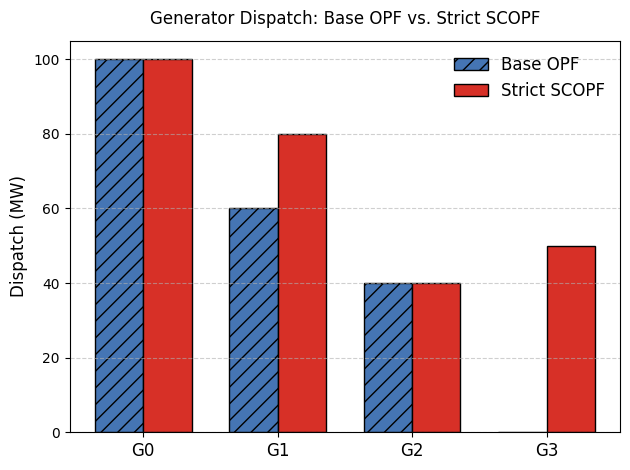

In [13]:
for i, gen in enumerate(generators):
    for j, mode in enumerate(["Base OPF", "Strict SCOPF"]):
        val = dispatch_all[(dispatch_all["Generator"] == gen) & (dispatch_all["type"] == mode)]["Dispatch"].values[0]
        offset = -0.18 if mode == "Base OPF" else 0.18
        plt.bar(i + offset, val, width=0.36, 
                color=colors[mode], 
                hatch=hatch[mode], 
                edgecolor="k", 
                label=mode if i == 0 else None)

plt.xticks(range(len(generators)), generators, fontsize=12)
plt.ylabel("Dispatch (MW)", fontsize=12)
plt.title("Generator Dispatch: Base OPF vs. Strict SCOPF", fontsize=12, pad=12)
plt.legend(fontsize=12, frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
print("Base OPF cost:", round(ofp_cost, 2))
print("Average SCOPF contingency cost:", round(np.mean(scopf_costs), 2))
print("Worst-case SCOPF contingency cost:", round(np.max(scopf_costs), 2))
print("Average unserved energy (MW) in SCOPF cases:", round(np.mean(scopf_unserved), 2))
print("Max unserved energy (MW) in SCOPF cases:", round(np.max(scopf_unserved), 2))

Base OPF cost: 4600.0
Average SCOPF contingency cost: 257773.33
Worst-case SCOPF contingency cost: 800800.0
Average unserved energy (MW) in SCOPF cases: 25.0
Max unserved energy (MW) in SCOPF cases: 80.0


Η σύγκριση των τιμών ισχύος (σε MW) μεταξύ των δύο μεθόδων αποκαλύπτει τις ακριβείς θυσίες και ανακατανομές που επιβάλλει η ασφάλεια $N-1$ στο σύστημα.

| Γεννήτρια (Τεχνολογία / Κόστος) | Base OPF (Οικονομικό) | Strict SCOPF (Ασφαλές) | Μεταβολή (MW) | Ερμηνεία & Συμπεριφορά |
| :--- | :---: | :---: | :---: | :--- |
| **G0** (Wind / 0 €) | 100 MW | 100 MW | 0 | **Πλήρης Αξιοποίηση:** Είναι η φθηνότερη πηγή και το δίκτυο την εξαντλεί στο 100% της ονομαστικής της ισχύος και στις δύο περιπτώσεις. |
| **G1** (Gas / 50 €) | 60 MW | 80 MW | +20 MW | **Ramping Up:** Στο SCOPF αναγκάζεται να δουλέψει στο μέγιστο της χωρητικότητάς της (80 MW) για να θωρακίσει τον κόμβο της. |
| **G2** (CHP / 40 €) | 40 MW | 40 MW | 0 | **Πλήρης Αξιοποίηση:** Ως η δεύτερη φθηνότερη επιλογή, τερματίζει και αυτή στο 100% της ισχύος της (40 MW) και στα δύο μοντέλα. |
| **G3** (Diesel / 200 €) | 0 MW | 50 MW | +50 MW | **Στρατηγική Εφεδρεία:** Ενώ στο οικονομικό OPF μένει σβηστή λόγω κόστους, στο SCOPF ανάβει προληπτικά στα 50 MW. |


### Tα Κρίσιμα Συμπεράσματα του Γραφήματος
#### 1. Το «Ασφάλιστρο» της Προληπτικής Λειτουργίας

- Στο Base OPF, η συνολική παραγωγή είναι ακριβώς ίση με τη ζήτηση:
$$\text{Total Load} = 100\text{ (G0)} + 60\text{ (G1)} + 40\text{ (G2)} + 0\text{ (G3)} = 200\text{ MW}$$
Αυτό είναι το απόλυτα φθηνότερο μείγμα.

- Στο Strict SCOPF, το άθροισμα των προληπτικών κατανομών (solid bars) ισούται με:
$$100 + 80 + 40 + 50 = 270\text{ MW}$$
Το σύστημα υποχρεώνει τις γεννήτριες να είναι προγραμματισμένες για υψηλότερη ισχύ (συνολικά $+70\text{ MW}$ διαθέσιμης ικανότητας). Αυτό το επιπλέον «περιθώριο» εξασφαλίζει ότι αν οποιαδήποτε γραμμή βγει εκτός, η ισχύς είναι ήδη γεωγραφικά κατανεμημένη με τέτοιο τρόπο ώστε οι εναπομείναντες διάδρομοι να μην ξεπεράσουν ποτέ τα θερμικά τους όρια ($s_{nom} = 100\text{ MW}$).

#### 2. Γιατί ενεργοποιείται το Diesel (G3);
- Η ενεργοποίηση του πανάκριβου Diesel στα $50\text{ MW}$ είναι η πιο τρανή απόδειξη της γεωγραφικής ευαισθησίας. Το Diesel βρίσκεται στο Bus 3. Αν απομονωθεί ή αν συμπιεστεί ο κλάδος του δακτυλίου που τροφοδοτεί το Bus 3, η φθηνή ενέργεια από τον Βορρά (G0) δεν μπορεί να φτάσει εκεί λόγω συμφόρησης των γραμμών. Το SCOPF το γνωρίζει αυτό εκ των προτέρων, οπότε «θυσιάζει» την οικονομία και ανάβει την G3, εξαλείφοντας τον κίνδυνο blackout στην περιοχή εκείνη.

---